In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [3]:
adults_df = pd.read_csv("../week_06/adult.csv")
adults_df.columns = ['age', 'workclass', 'sampling weight', 'education', 'education num', 'marital status', 'occupation',
                     'relationship', 'race', 'sex', 'capital gain', 'capital loss', 'hours per week', 'native country', 'income']
adults_df.head()

,age,workclass,sampling weight,education,education num,marital status,occupation,relationship,race,sex,capital gain,capital loss,hours per week,native country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [4]:
column_change = ['workclass', 'marital status', 'occupation', 'relationship', 'race', 'sex', 'native country', 'income']
for col in column_change:
    adults_df[col] = adults_df[col].astype(str).str.strip()

In [5]:
adults_df['workclass'] = adults_df['workclass'].astype(str).str.strip()
adults_df['marital status'] = adults_df['marital status'].astype(str).str.strip()


# workclass mapping
workclass_map = {'Private': 0, 'Self-emp-not-inc': 1, 'Local-gove': 2, 'State-gov': 3, 'Self-emp-inc': 4,'Federal-gov': 5, 'Without-pay': 6, 'Never-worked': 7}
adults_df['workclass'] = adults_df['workclass'].map(workclass_map)

# education drop, keep only education number
adults_df = adults_df.drop('education', axis=1)

# marital status mapping
marital_status_map = {'Never-married': 0, 'Married-civ-spouse': 1, 'Divorced': 2, 'Married-spouse-absent': 3, 'Separated': 4, 'Married-AF-spouse': 5, 'Widowed': 6}
adults_df['marital status'] = adults_df['marital status'].map(marital_status_map)

# occupation mapping
occupation_map = {'Adm-clerical': 0, 'Exec-managerial': 1, 'Handlers-cleaners': 2, 'Prof-specialty': 3, 'Other-service': 4, 'Sales': 5, 'Craft-repair': 6,
                  'Transport-moving': 7, 'Farming-fishing': 8, 'Machine-op-inspct': 9, 'Tech-support': 10, 'Protective-serv': 11, 'Armed-Forces': 12}
adults_df['occupation'] = adults_df['occupation'].map(occupation_map)

# relationship mapping
relationship_map = {'Not-in-family': 0, 'Husband': 1, 'Wife': 2,  'Own-child': 3, 'Unmarried': 4, 'Other-relative': 5}
adults_df['relationship'] = adults_df['relationship'].map(relationship_map)

# race mapping
race_map = {'White': 0, 'Black': 1, 'Asian-Pac-Islander': 2, 'Amer-Indian-Eskimo': 3, 'Other': 4}
adults_df['race'] = adults_df['race'].map(race_map)

# sex mapping
sex_map = {'Male': 0, 'Female': 1}
adults_df['sex'] = adults_df['sex'].map(sex_map)

#native country mapping
native_country_map = {'United-States': 1, 'Cuba': 2, 'Jamaica': 3, 'India': 4, '?': 5, 'Mexico': 6, 'South': 7,
                     'Puerto-Rico': 8, 'Honduras': 9, 'England': 10, 'Canada': 11, 'Germany': 12, 'Iran': 13,
                     'Philippines': 14, 'Italy': 15, 'Poland': 16, 'Columbia': 17, 'Cambodia': 18, 'Thailand': 19,
                     'Ecuador': 20, 'Laos': 21, 'Taiwan': 22, 'Haiti': 23, 'Portugal': 24, 'Dominican-Republic': 25,
                     'El-Salvador': 26, 'France': 27, 'Guatemala': 28, 'China': 29, 'Japan': 30, 'Yugoslavia': 31,
                     'Peru': 32, 'Outlying-US(Guam-USVI-etc)':33,'Scotland' :34,'Trinadad&Tobago' :35,
                     'Greece': 36, 'Nicaragua': 37, 'Vietnam': 38, 'Hong': 39, 'Ireland': 40, 'Hungary': 41,
                     'Holand-Netherlands': 42}
adults_df['native country'] = adults_df['native country'].map(native_country_map)

# income country mapping
income_mapping = {'<=50K': 0, '>50K': 1}
adults_df['income']  = adults_df['income'].map(income_mapping)

adults_df.head()

,age,workclass,sampling weight,education num,marital status,occupation,relationship,race,sex,capital gain,capital loss,hours per week,native country,income
0,50,1.0,83311,13,1,1.0,1,0,0,0,0,13,1,0
1,38,0.0,215646,9,2,2.0,0,0,0,0,0,40,1,0
2,53,0.0,234721,7,1,2.0,1,1,0,0,0,40,1,0
3,28,0.0,338409,13,1,3.0,2,1,1,0,0,40,2,0
4,37,0.0,284582,14,1,1.0,2,0,1,0,0,40,1,0


In [6]:
print(adults_df.isna().sum())  

age                   0
workclass          3929
sampling weight       0
education num         0
marital status        0
occupation         1992
relationship          0
race                  0
sex                   0
capital gain          0
capital loss          0
hours per week        0
native country        0
income                0
dtype: int64


In [7]:
num_cols = adults_df.select_dtypes(include=['int64','float64']).columns
adults_df[num_cols] = adults_df[num_cols].fillna(adults_df[num_cols].median())

In [8]:
from sklearn.model_selection import train_test_split

X = adults_df.drop('income',axis=1)
y = adults_df['income']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=50)
                                                    


In [9]:
model = tree.DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

In [10]:
model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      7370
           1       0.57      0.84      0.68      2398

    accuracy                           0.81      9768
   macro avg       0.76      0.82      0.77      9768
weighted avg       0.85      0.81      0.82      9768



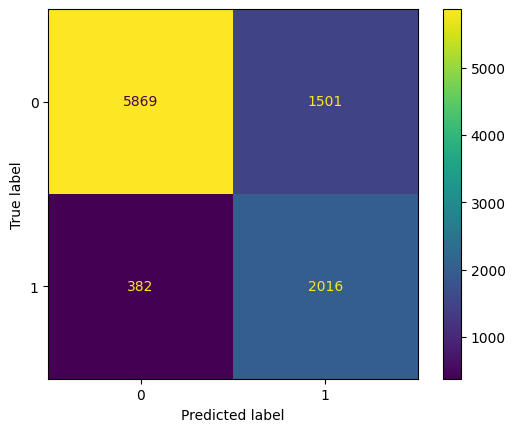

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [12]:
#Recall
2016/(2016+382)

0.8407005838198499

I improve this dataset by replace NaN with the median number for each column. I also use decision tree classifier, and I think it really help improving the model when we can add and adjust some factors in consideration. 

Question 2:

Oversampling

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = adults_df.drop('income', axis=1)
y = adults_df['income']

X_train, X_test, y_train, y_test = train_test_split(
                                                X,y, test_size=0.3,
                                                random_state=42,
                                                stratify=y)

In [14]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [15]:
model = LogisticRegression(random_state=42)
model.fit(X_resampled, y_resampled)

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test)

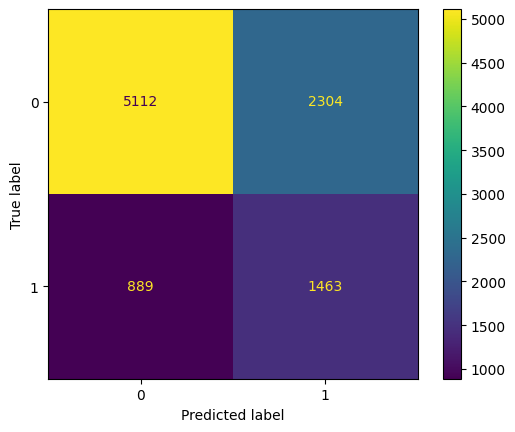

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [18]:
# Recall 
1463/(1463+889)

0.6220238095238095

Undersampling

In [19]:
from imblearn.under_sampling import ClusterCentroids

rus = ClusterCentroids(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
model = LogisticRegression(random_state=42)
model.fit(X_resampled, y_resampled)

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred = model.predict(X_test)

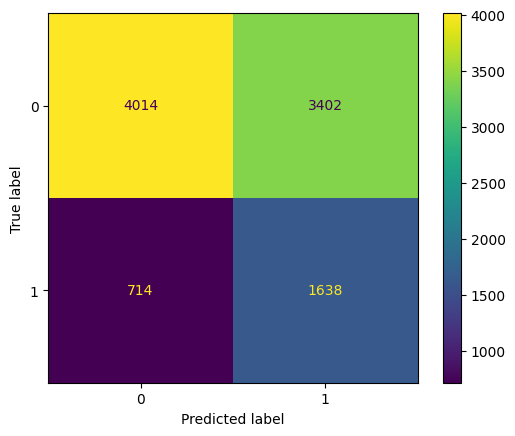

In [21]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [22]:
# Recall
1638/(1638+714)

0.6964285714285714

After performing oversampling and undersampling, I can see that the recall increased from around 0.6 to around 0.622 and 0.699 respectively. So this means that performing over and undersampling have improved the results of knn and Logistic Regression. I think oversampling increase the presence of minority samples, which help make the model learns better and reduce the false positive. Similar to that idea, undersampling will reduce the majority samples, which help the model learns minority patterns better and improve the recall, but can reduce the overall accuracy.

Question 3:

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


C:\Users\hp\AppData\Local\Temp\ipykernel_3156\96222079.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


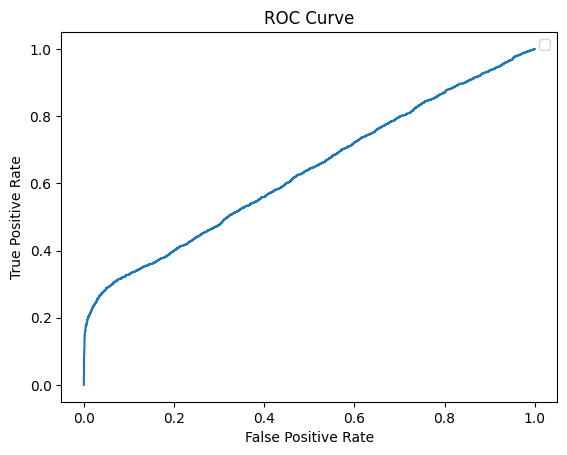

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_scores = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)
print(fpr, tpr)

[0.         0.45873786 1.        ] [0.         0.69642857 1.        ]


In [26]:
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

AUC: 0.6188453536754508


Question 4:

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = adults_df.drop('income', axis=1)
y = adults_df['income']

X_train, X_test, y_train, y_test = train_test_split(
                                                X,y, test_size=0.3,
                                                random_state=42,
                                                stratify=y)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("SVM Results:")
print(classification_report(y_test, y_pred))

This SVM model takes too long to train and I am not sure if my code is correct or not. I don't have result for this question, so I can not tell how well this model perform.

Question 5:

Outlier detection means finding data points that are very different from most other points in your dataset. These are values that are too high, too low, or just strange compared to the rest. Outliers can happen because of mistakes when collecting data. I think outliers are important because they can mess up the results, like they can make averages, percentages, or predictions wrong. It can also make the machine learning models results from KNN or SVM get confused and misunderstood if there are outliers. But sometimes outliers are useful because they can show fraud, errors, or rare events that are important. We can use visualization like boxplot graph, statistical methods like interquatile range, or machine learning method like isolation forest.